## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [2]:
import os
# Set CPU math thread limits before importing numpy/torch-backed libraries.
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"

import h5py
import numpy as np

DATA_NAME = "SEED"
INDEX_PATH_TRAIN = f"/root/autodl-tmp/MLproject/course_project/{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"/root/autodl-tmp/MLproject/course_project/{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"/root/autodl-tmp/MLproject/course_project/{DATA_NAME}/test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))


keys: ['X', 'y']
x dtype: float32
x shape: (900, 62, 400)
y dtype: int64
y shape: (900,)
unique: [0 1 2]


## 2) 定义模型：SimpleLinear
最简单的线性分类器，方便和更复杂模型对比。


In [30]:
import torch
import torch.nn as nn

class SimpleLinear(nn.Module):
    def __init__(self, input_channels, time_points, num_classes):
        super(SimpleLinear, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_channels * time_points, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)


## 3) 定义模型：SimpleMLP
把输入拉平后通过多层全连接网络进行分类，表达能力比线性模型更强。


In [31]:
class SimpleMLP(nn.Module):
    def __init__(
        self,
        input_channels,
        num_classes,
        time_points=200,
        hidden_dims=(256, 128),
        dropout=0.3
    ):
        super().__init__()

        input_dim = input_channels * time_points

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))

        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, C, T)
        x = self.flatten(x)      # -> (B, C*T)
        logits = self.mlp(x)     # -> (B, num_classes)
        return logits

## 4) 定义模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline


In [32]:
class EEGNet(nn.Module):  # EEGNet-8,2
    def __init__(self, chans,time_point=200,f1=8, d=2, pk1=4, pk2=8, dp=0.5, max_norm1=1,norm=torch.nn.Identity()):
        super(EEGNet, self).__init__()
        f2 = f1 * d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0,32), bias=False),
            nn.BatchNorm2d(f1),
        )
        # Spatial Filters
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),  # Depthwise Conv
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding=(0,8)),  # Separable Conv
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),  # Pointwise Conv
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        self._apply_max_norm(self.block2[0], max_norm1)
        self.embed_dim = f2 * ((time_point // pk1) // pk2)
        self.norm=norm


    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        self.norm(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(dim=1)
        x = self.block1(x.unsqueeze(dim=1))
        x = self.block2(x)
        x = self.block3(x)
        return x.flatten(start_dim=1)

## 5) 导入模型：EEGGRU
这里希望同学们自己手搓一个RNN代码，试试RNN的训练效果如何


In [5]:
# GPU environment configuration
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# Enable TF32 matmul/convolution on Ampere/Ada/Blackwell GPUs for faster training.
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

from RNN import EEGGRU


Using device: cuda:0
GPU name: NVIDIA GeForce RTX 5090


## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


Epoch [01/100] | Train Loss: 1.1125 | Val Loss: 1.1007 | Val Acc: 0.3311 | Best Val Acc: 0.3311 @ 01 | Bad Epochs: 0/50 | 
Epoch [02/100] | Train Loss: 1.1032 | Val Loss: 1.0977 | Val Acc: 0.3622 | Best Val Acc: 0.3622 @ 02 | Bad Epochs: 0/50 | 
Epoch [03/100] | Train Loss: 1.1050 | Val Loss: 1.0999 | Val Acc: 0.3333 | Best Val Acc: 0.3622 @ 02 | Bad Epochs: 1/50 | 
Epoch [04/100] | Train Loss: 1.1018 | Val Loss: 1.0979 | Val Acc: 0.3378 | Best Val Acc: 0.3622 @ 02 | Bad Epochs: 2/50 | 
Epoch [05/100] | Train Loss: 1.0958 | Val Loss: 1.0976 | Val Acc: 0.3333 | Best Val Acc: 0.3622 @ 02 | Bad Epochs: 3/50 | 
Epoch [06/100] | Train Loss: 1.1006 | Val Loss: 1.0987 | Val Acc: 0.3822 | Best Val Acc: 0.3822 @ 06 | Bad Epochs: 0/50 | 
Epoch [07/100] | Train Loss: 1.0983 | Val Loss: 1.0974 | Val Acc: 0.3533 | Best Val Acc: 0.3822 @ 06 | Bad Epochs: 1/50 | 
Epoch [08/100] | Train Loss: 1.0969 | Val Loss: 1.0966 | Val Acc: 0.3689 | Best Val Acc: 0.3822 @ 06 | Bad Epochs: 2/50 | 
Epoch [09/100] |

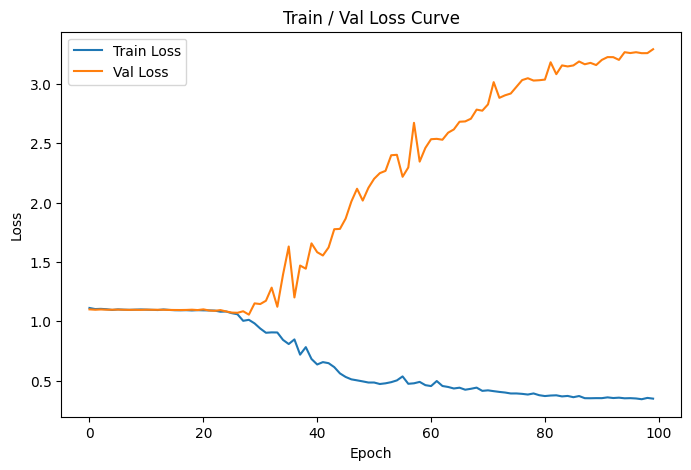

In [22]:
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from course_project.TEST_DATASET import TrainDataset, TestDataset


CHANNELS = 62
patch_size = 400
CLASSES = 3
BATCH_SIZE = 32
EPOCHS = 100
LR = 5e-4
PATIENCE = 50
MIN_DELTA = 0.0
BEST_MODEL_PATH = f"course_project/{DATA_NAME}/best_seed_bigru.pt"
USE_CUDA = device.type == "cuda"

# -------------------------
# Data
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)

# pin_memory/non_blocking speed up host->GPU copies when CUDA is available.
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=USE_CUDA,
    num_workers=4,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=USE_CUDA,
    num_workers=4,
    persistent_workers=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    pin_memory=USE_CUDA,
    num_workers=1,
    persistent_workers=True,
)

# -------------------------
# Model, loss, optimizer, scheduler
# -------------------------
#model = SimpleMLP(input_channels=CHANNELS,time_points=200,num_classes=CLASSES)
#model = nn.Sequential(EEGNet(chans=CHANNELS, time_point=patch_size), nn.Linear(96, CLASSES))
model = EEGGRU(chans=CHANNELS, hidden_dim=64, num_layers=2, num_classes=CLASSES, bidirectional=True)
model = model.to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=8,
)

# -------------------------
# Metrics and early stopping state
# -------------------------
train_losses = []
val_losses = []
val_accuracies = []
best_val_acc = -1.0
best_epoch = 0
bad_epochs = 0

# -------------------------
# Training loop
# -------------------------
for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_num = 0

    for data, label in train_loader:
        data = data.to(device, dtype=torch.float32, non_blocking=USE_CUDA)
        label = label.to(device, dtype=torch.long, non_blocking=USE_CUDA)

        optimizer.zero_grad(set_to_none=True)

        output = model(data)
        loss = criterion(output, label)

        loss.backward()
        # grad_norm = model.clip_gradients()
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

    epoch_train_loss = train_loss_sum / train_num
    train_losses.append(epoch_train_loss)

    # ===== Val =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data = val_data.to(device, dtype=torch.float32, non_blocking=USE_CUDA)
            val_label = val_label.to(device, dtype=torch.long, non_blocking=USE_CUDA)

            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    scheduler.step(epoch_val_acc)

    improved = epoch_val_acc > best_val_acc + MIN_DELTA
    if improved:
        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        bad_epochs = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        bad_epochs += 1

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"Best Val Acc: {best_val_acc:.4f} @ {best_epoch:02d} | "
        f"Bad Epochs: {bad_epochs}/{PATIENCE} | "
    )

    if bad_epochs >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}; best epoch was {best_epoch} with val acc {best_val_acc:.4f}.")
        break

# Load the best checkpoint before plotting and test inference.
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

# -------------------------
# Final validation accuracy
# -------------------------
print("\n" + "-" * 40)
print(f"Best Val Accuracy: {best_val_acc:.4f} (epoch {best_epoch})")
print(f"Best model saved to: {BEST_MODEL_PATH}")

# -------------------------
# Train / val loss curve
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.legend()
plt.savefig("./loss_curve.png")
# plt.show()

# -------------------------
# Test inference example
# -------------------------
test_data = next(iter(test_loader))
test_data = test_data.to(device, dtype=torch.float32, non_blocking=USE_CUDA)
test_pred = model(test_data)
print("-" * 40)
print("Test input shape:", test_data.shape)
print("Test output shape:", test_pred.shape)


## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [20]:
# -------------------------
# Save test prediction labels, one label per line
# -------------------------
model.eval()
output_path = f'course_project/{DATA_NAME}/{DATA_NAME}.txt'

all_test_labels = []
with torch.no_grad():
    for test_data in test_loader:  # test_loader is already shuffle=False
        test_data = test_data.to(device, dtype=torch.float32, non_blocking=USE_CUDA)
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")


Saved 450 labels to: course_project/SEED/SEED.txt
